In [4]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import time

In [5]:
# calcula a transformada rápida de fourier
def FFT(x,N):

  if N == 1:
    return x


  Xp = FFT(x[::2], N//2)
  Xi = FFT(x[1::2], N//2)
  X = np.zeros(N, dtype=complex)
  W_N = np.exp(-1j * 2 * np.pi/N *np.arange(N))
  return np.concatenate([Xp + W_N[:N//2] * Xi, Xp + W_N[N//2:] * Xi])


# calcula a trasnsformada de rápida de fourier inversa
def IFFT_(x,N):

  if N == 1:
    return x

  Xp = IFFT_(x[::2], N//2)
  Xi = IFFT_(x[1::2], N//2)
  X = np.zeros(N, dtype=complex)
  W_N = np.exp(1j * 2 * np.pi/N *np.arange(N))
  return np.concatenate([Xp + W_N[:N//2] * Xi, Xp + W_N[N//2:] * Xi])

def IFFT(x,N):
  return (1/N) * IFFT_(x,N)

# Adiciona zeros para completar a matriz com N elementos(aumentando a precisão do gráfico)
def zero_padding(N,x):
  while len(x) < N:
    x.append(0)

  return x


# plot de gráficos interativos
def stem_plot_plotly(x, y, title='Stem Plot', y_label='Amplitude'):
    fig = go.Figure()

    # Linhas verticais
    for xi, yi in zip(x, y):
        fig.add_trace(go.Scatter(
            x=[xi, xi],
            y=[0, yi],
            mode='lines',
            line=dict(color='blue'),
            showlegend=False
        ))

    # Marcadores no topo das hastes
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color='blue', size=8),
        name='valor'
    ))

    # Linha de base
    fig.add_trace(go.Scatter(
        x=[x[0], x[-1]],
        y=[0, 0],
        mode='lines',
        line=dict(color='red', width=1),
        showlegend=False
    ))

    # atualiza gráfico
    fig.update_layout(
        title=title,
        xaxis_title='(k)',
        yaxis_title=y_label,
        height=400
    )

    fig.show()

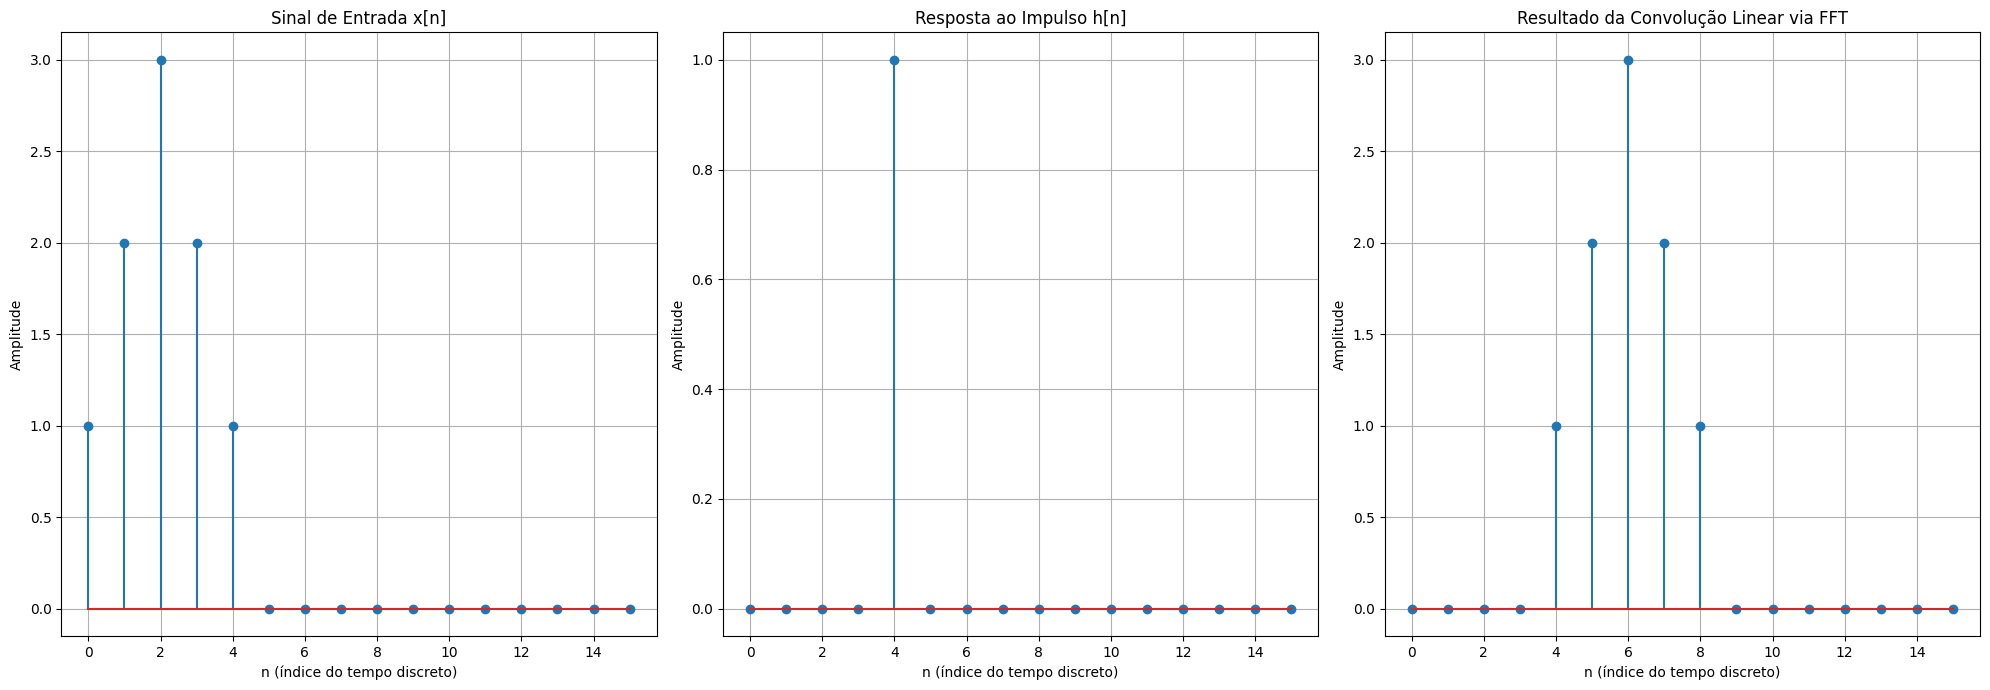

In [19]:
#sinal de entrada(+ ajuste de dimensão caso o vetor seja diferente de N)

x = [1,2,3,2, 1]
h = [0,0,0,0,1]

#determina número de amostras
N = int(2 ** np.ceil(np.log2(len(x) + len(h) -1 )))

#aplica zero pedding nos sinais de entrada e resposta ao imoulso respectivamente
x = np.pad(x, (0, N - len(x)), 'constant')
h = np.pad(h, (0, N - len(h)), 'constant')

# aplica transformada de fourier no sinal de entrada
fftx = FFT(x,N)

#aplica a transformada de fourier no sinal de resposta ao impulso
ffth = FFT(h,N)

#calcula a convolução
Conv_linear = IFFT(fftx*ffth, N)



#plota o resultado

plt.figure(figsize=(20, 7))

# Sinal de entrada x[n]
plt.subplot(1, 3, 1)
plt.stem(x)  # mostra só a parte original, sem o padding
plt.title("Sinal de Entrada x[n]")
plt.xlabel("n (índice do tempo discreto)")
plt.ylabel("Amplitude")
plt.grid(True)

# Resposta ao impulso h[n]
plt.subplot(1, 3, 2)
plt.stem(h)  # mostra só a parte original, sem o padding
plt.title("Resposta ao Impulso h[n]")
plt.xlabel("n (índice do tempo discreto)")
plt.ylabel("Amplitude")
plt.grid(True)

# Resultado da convolução
plt.subplot(1, 3, 3)
plt.stem(Conv_linear.real[:len(x) + len(h) - 1])
plt.title("Resultado da Convolução Linear via FFT")
plt.xlabel("n (índice do tempo discreto)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()


